# 🐧 Penguin Clustering Analysis
**Course:** Unsupervised Learning in Python (DataCamp)  
**Program:** THRIVE ML Specialization, Kiron Open Higher Education  

## Overview
This project applies k-means clustering to the Palmer Penguins dataset 
to identify natural groupings in penguin physical measurements using 
unsupervised machine learning techniques.

## Methods
- Exploratory data analysis
- Dummy encoding for categorical features
- Feature scaling with StandardScaler
- Elbow analysis for optimal k selection
- KMeans clustering
- Cluster visualization and interpretation

![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

## 1. Import Libraries

In [50]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 2. Load and Explore Data

In [51]:
# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


## 3. Data Preprocessing

In [52]:
dummies = pd.get_dummies(penguins_df["sex"], drop_first=True)
penguins_df = penguins_df.drop("sex", axis=1)
penguins_df = pd.concat([penguins_df, dummies], axis=1)


### Recommended: standardizing/scaling before clustering

In [53]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(penguins_df)

## 4. Finding Optimal Clusters
Perform Elbow analysis to determine the optimal number of clusters for this dataset.

### Perform Elbow analysis
1. Create an empty list to store the inertia for a range of KMeans models with varying numbers of clusters.
2. Perform Elbow analysis using a for loop for the number of clusters ranging from 1 to 9 inclusive, i.e., for i in range(1,10).
3. Inside the for loop, use the KMeans(n_clusters=k, random_state=42).fit(...) function to fit the data.
4. Access the inertia value for each cluster using the kmeans.inertia_ attribute and store it in the previously created empty list.
5. Visualize the list of inertia values to determine the optimal number of clusters for the dataset, where the inertia begins to decrease more _slowly_

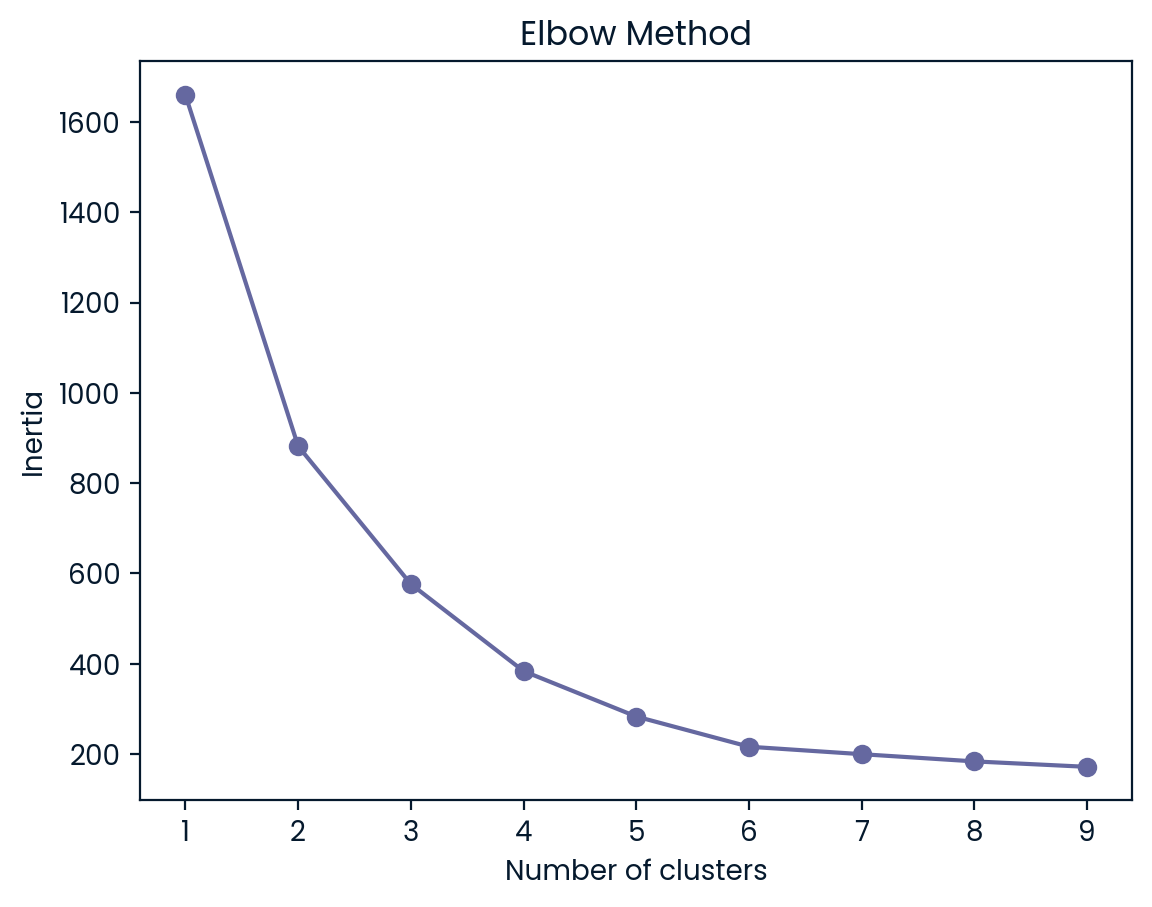

In [54]:
# Create empty list to store inertia values
inertia = []

# Elbow analysis loop
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Visualize the elbow curve
plt.plot(range(1, 10), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## 5. Clustering

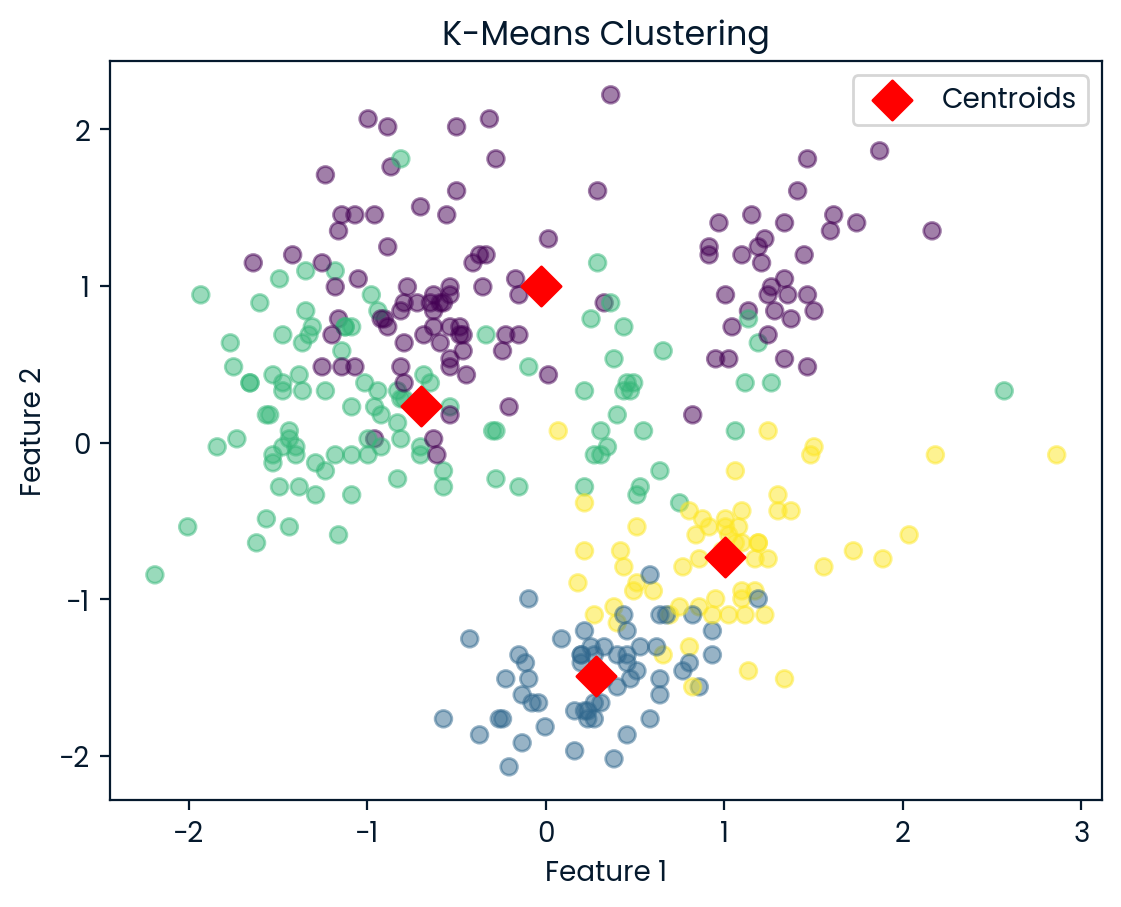

2    107
0    106
3     61
1     58
Name: cluster, dtype: int64


In [55]:
# Fit k-means with optimal number of clusters 
elbow = 4
kmeans = KMeans(n_clusters=elbow, random_state=42)
kmeans.fit(df_scaled)

# Get cluster labels
labels = kmeans.labels_

# Add cluster labels back to original DataFrame
penguins_df["cluster"] = labels

# Visualize the clusters
plt.scatter(df_scaled[:, 0], df_scaled[:, 1], c=labels, cmap="viridis", alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker="D", s=100, color="red", label="Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

# Check cluster distribution
print(penguins_df["cluster"].value_counts())

## 6. Visualization
Create a final characteristic DataFrame for each cluster using the groupby method and mean function only on numeric columns.

In [56]:
numeric_columns = [col for col in penguins_df.select_dtypes(include="number").columns
                   if penguins_df[col].nunique() > 2]

penguins_df["label"] = kmeans.labels_

stat_penguins = penguins_df.groupby("label")[numeric_columns].mean()

stat_penguins

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,cluster
label,,,,,
0,43.878302,19.111321,194.764151,4006.603774,0.0
1,45.563793,14.237931,212.706897,4679.741379,1.0
2,40.217757,17.611215,189.046729,3419.158879,2.0
3,49.473770,15.718033,221.540984,5484.836066,3.0


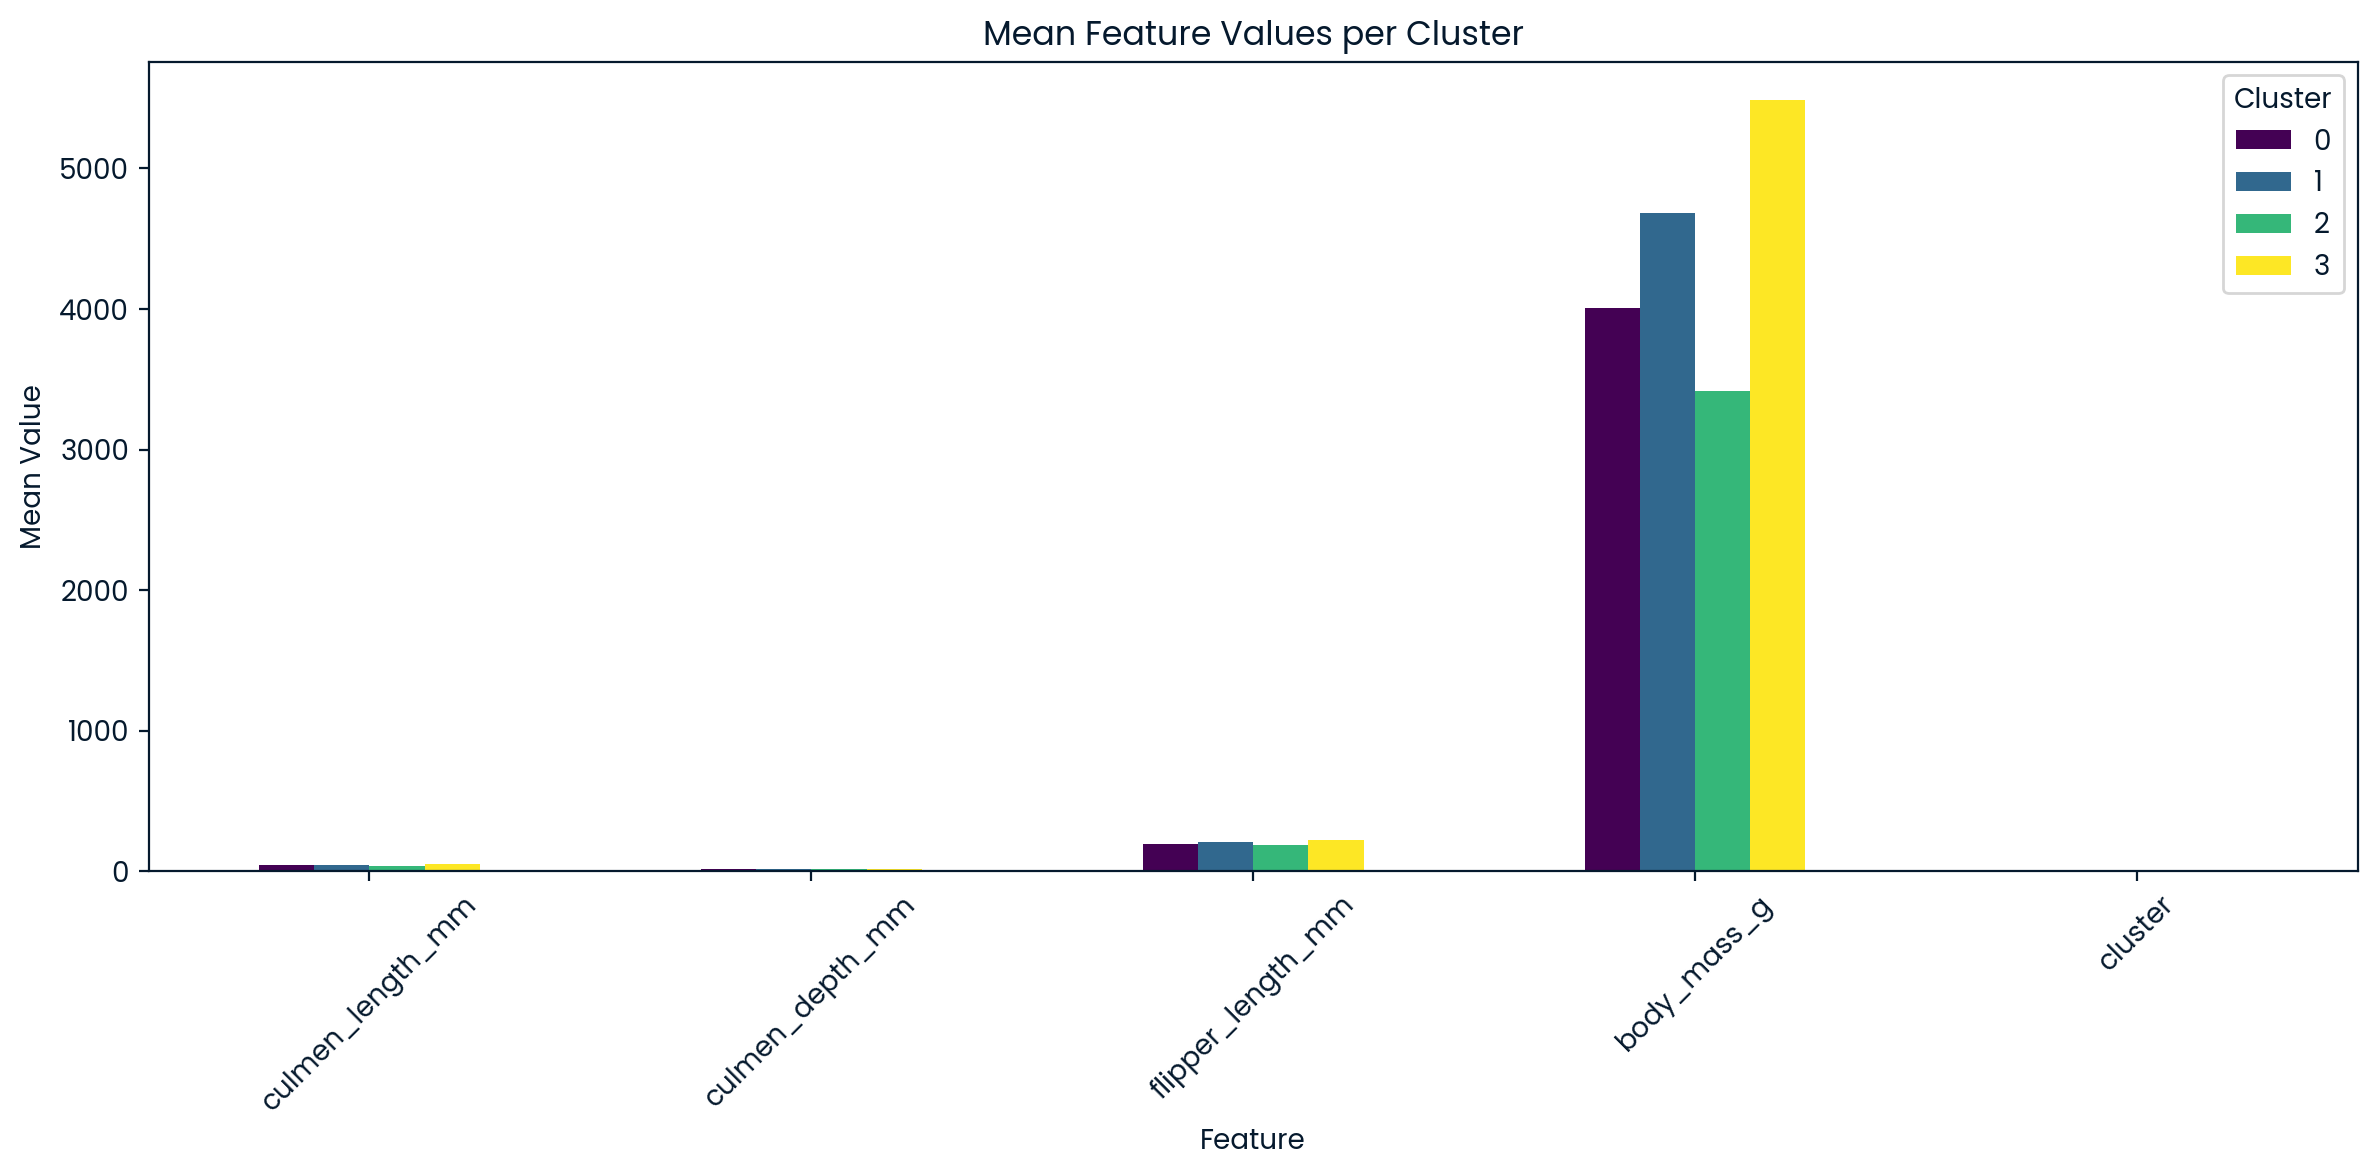

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Bar chart of mean values per cluster per feature
stat_penguins.T.plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Mean Feature Values per Cluster")
plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 7. Cluster Interpretation

The bar chart compares the mean value of each physical measurement across the three clusters. Each group of bars represents one feature, and each color represents a cluster. Clusters that differ visibly in body mass and flipper length are likely to represent penguin groups with distinct physical builds. If one cluster consistently shows higher bars across all features, it likely corresponds to the largest penguin species in the dataset.

## 8. Summary and Conclusions

## Conclusions

Three distinct clusters were identified in the Palmer Penguins dataset:

- **Cluster 0:** smaller body mass and shorter flippers, likely Adelie penguins
- **Cluster 1:** medium measurements across all features, likely Chinstrap penguins  
- **Cluster 2:** largest body mass and longest flippers, likely Gentoo penguins

Feature scaling was essential for this analysis. Without StandardScaler, 
body mass (in grams) would have dominated the distance calculations due 
to its larger scale compared to bill measurements (in mm).

## Attribution and License

The dataset used in this project (Palmer Penguins) is publicly available.

This project was completed as part of the 
[Unsupervised Learning in Python](https://app.datacamp.com/learn/courses/unsupervised-learning-in-python) 
course on DataCamp, within the THRIVE ML Specialization program by 
Kiron Open Higher Education.

The code and analysis in this notebook is my own work, written and 
adapted from course exercises for learning and portfolio purposes.

© Paulie Yap, 2026